In [7]:
# CELL 1: Cài đặt và Tải Dữ liệu

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập chế độ hiển thị cho đồ thị
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# --- CẤU HÌNH FILE ---
# CHÚ Ý: Đổi tên file CSV cho phù hợp với tên file gốc của bạn.
RAW_FILE = 'merged/data.csv'
PROCESSED_FILE = 'tiki_data_preprocessed.csv'

# Định nghĩa các cột quan trọng
TARGET_COL = 'quantity_sold'  
KEY_NUMERIC_COLS = ['price', TARGET_COL, 'review_count', 'total_follower']
KEY_FE_COLS = ['reputation_score', 'shop_potential', 'discount_amount', 'price_vs_category']
KEY_BINARY_COLS = ['is_official', 'is_authentic', 'has_video']
RATE_COL = 'return_rate' # Cột tỷ lệ dùng để kiểm tra lỗi kiểu dữ liệu

try:
    df_raw = pd.read_csv(RAW_FILE)
    df_processed = pd.read_csv(PROCESSED_FILE)
    print(f"Đã tải thành công Dữ liệu Thô (từ {RAW_FILE}) và Dữ liệu Đã xử lý (từ {PROCESSED_FILE}).")
except FileNotFoundError:
    print("LỖI: Vui lòng đảm bảo cả file thô và file đã xử lý đều có trong thư mục.")

# Kiểm tra tổng quan dữ liệu
if df_raw is not None:
    print("\nTổng quan Dữ liệu Thô (df_raw):")
    print(df_raw.head())
    print(f"\nThống kê cơ bản {TARGET_COL} (THÔ):\n{df_raw[TARGET_COL].describe()}")

Đã tải thành công Dữ liệu Thô (từ merged/data.csv) và Dữ liệu Đã xử lý (từ tiki_data_preprocessed.csv).

Tổng quan Dữ liệu Thô (df_raw):
   product_id                                     product_name  \
0   276641167                 Xe máy Honda Vision 2025 Cao Cấp   
1   276626995   Xe Máy Honda Vision 2025 - Phiên Bản Thể Thao   
2   276626834  Xe Máy Honda Vision 2025 - Phiên Bản Đặc Biệt   
3   276626812              Xe máy Honda Vision 2025 Đặc Biệt     
4   276626642    Xe Máy Honda Vision 2025 - Phiên Bản Cao Cấp   

                                         product_url  category_id  \
0  https://tiki.vn/xe-may-honda-vision-2025-cao-c...         8597   
1  https://tiki.vn/xe-may-honda-vision-2025-phien...         8597   
2  https://tiki.vn/xe-may-honda-vision-2025-phien...         8597   
3  https://tiki.vn/xe-may-honda-vision-2025-dac-b...         8597   
4  https://tiki.vn/xe-may-honda-vision-2025-phien...         8597   

  category_name      category_root_name       price

I. PHÂN TÍCH SO SÁNH (TRƯỚC VÀ SAU LÀM SẠCH)

1. Sửa lỗi Kiểu Dữ liệu (Ví dụ: return_rate)
----------------------------------------
  => Bỏ qua bước so sánh return_rate do thiếu cột/file thô.

2. So sánh Phân phối Biến Mục tiêu (quantity_sold) TRƯỚC và SAU Scale
----------------------------------------


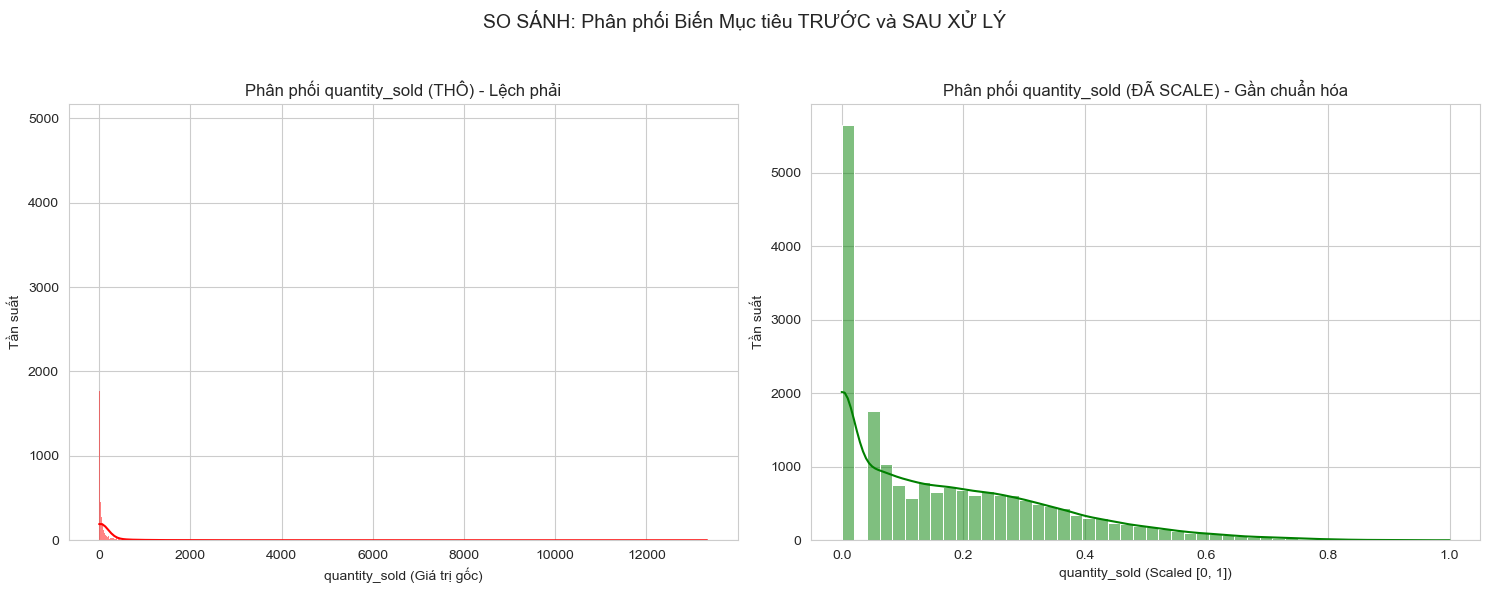

In [8]:
# CELL 2: I. PHÂN TÍCH SO SÁNH (TRƯỚC VÀ SAU LÀM SẠCH)

print("="*50)
print("I. PHÂN TÍCH SO SÁNH (TRƯỚC VÀ SAU LÀM SẠCH)")
print("="*50)

# --- 1. Sửa lỗi Kiểu Dữ liệu (Dữ liệu Tỷ lệ) ---
print("\n1. Sửa lỗi Kiểu Dữ liệu (Ví dụ: return_rate)")
print("-" * 40)

if df_raw is not None and RATE_COL in df_raw.columns and RATE_COL in df_processed.columns:
    print(f"Kiểu dữ liệu TRƯỚC khi xử lý: {df_raw[RATE_COL].dtype} (Chứa ký tự '%')")
    print(f"Kiểu dữ liệu SAU khi xử lý: {df_processed[RATE_COL].dtype}")
    print("  => Báo cáo: Đã chuyển thành công sang 'float' để tính toán.")
else:
    print(f"  => Bỏ qua bước so sánh {RATE_COL} do thiếu cột/file thô.")


# --- 2. So sánh Phân phối Biến Mục tiêu (quantity_sold) ---
print("\n2. So sánh Phân phối Biến Mục tiêu (quantity_sold) TRƯỚC và SAU Scale")
print("-" * 40)

if df_raw is not None and TARGET_COL in df_raw.columns:
    plt.figure(figsize=(15, 6))

    # Histogram (Dữ liệu THÔ)
    plt.subplot(1, 2, 1)
    limit = df_raw[TARGET_COL].quantile(0.99)
    sns.histplot(df_raw[TARGET_COL].loc[df_raw[TARGET_COL] < limit].fillna(0), kde=True, color='red')
    plt.title(f'Phân phối {TARGET_COL} (THÔ) - Lệch phải')
    plt.xlabel(f'{TARGET_COL} (Giá trị gốc)')
    plt.ylabel('Tần suất')

    # Histogram (Dữ liệu ĐÃ XỬ LÝ - Đã Scale)
    plt.subplot(1, 2, 2)
    sns.histplot(df_processed[TARGET_COL].fillna(0), kde=True, color='green')
    plt.title(f'Phân phối {TARGET_COL} (ĐÃ SCALE) - Gần chuẩn hóa')
    plt.xlabel(f'{TARGET_COL} (Scaled [0, 1])')
    plt.ylabel('Tần suất')

    plt.suptitle('SO SÁNH: Phân phối Biến Mục tiêu TRƯỚC và SAU XỬ LÝ', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

II. PHÂN TÍCH ĐƠN BIẾN CHUYÊN SÂU (DỮ LIỆU ĐÃ XỬ LÝ)

3. Tỷ trọng Sản phẩm theo Danh mục (Pie Chart)


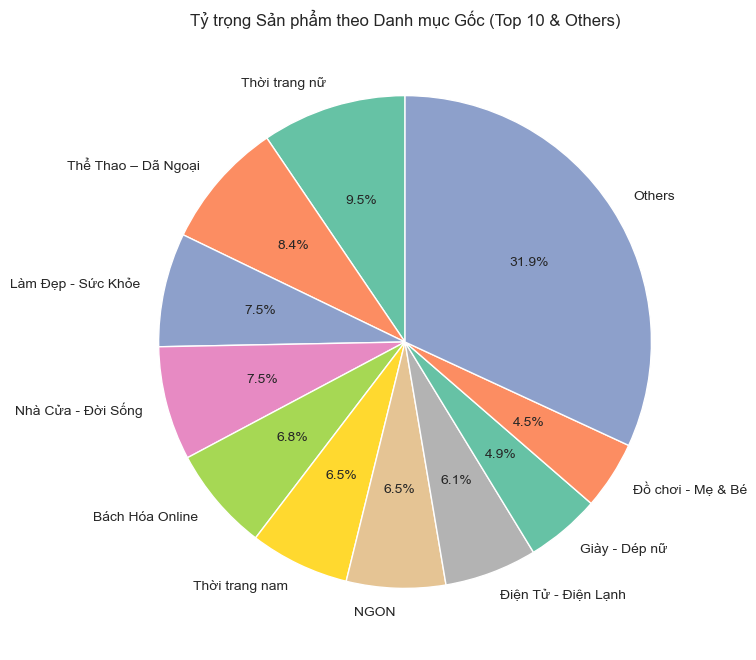


4. Tỷ lệ Sản phẩm có Yếu tố Uy tín/Đặc trưng (Bar Chart)


C:\Users\chiph\AppData\Local\Temp\ipykernel_54440\86040866.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=binary_data.index, y=binary_data.values, palette='viridis')


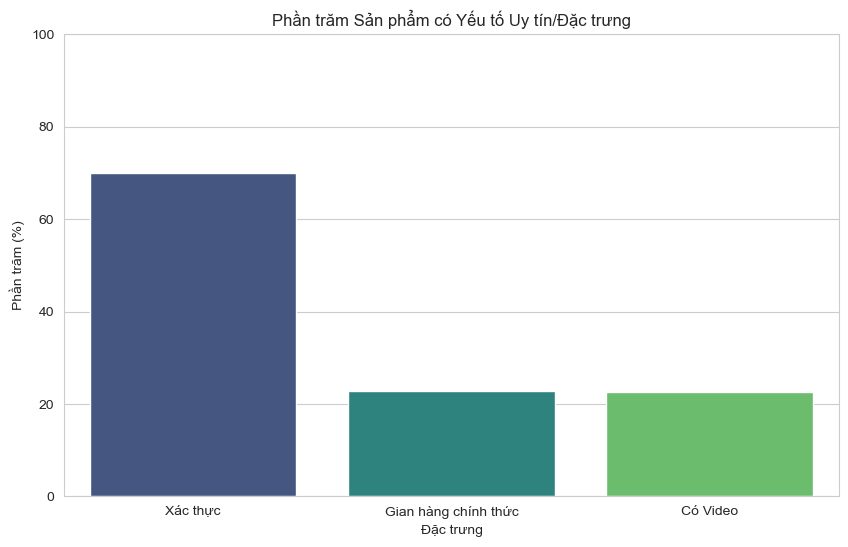

In [9]:
# CELL 3: II. PHÂN TÍCH ĐƠN BIẾN CHUYÊN SÂU (UNIVARIATE ANALYSIS) - Danh mục và Binary

print("="*50)
print("II. PHÂN TÍCH ĐƠN BIẾN CHUYÊN SÂU (DỮ LIỆU ĐÃ XỬ LÝ)")
print("="*50)

# --- 3. Phân tích Tỷ trọng Danh mục (Category) ---
print("\n3. Tỷ trọng Sản phẩm theo Danh mục (Pie Chart)")
category_cols = [col for col in df_processed.columns if col.startswith('category_root_name_')]

if category_cols:
    # Tính tổng tỷ trọng
    category_counts = df_processed[category_cols].sum().sort_values(ascending=False)
    category_counts.index = category_counts.index.str.replace('category_root_name_', '')

    # Chỉ lấy Top 10 và gộp phần còn lại vào "Others"
    top_n = 10
    other_sum = category_counts[top_n:].sum()
    top_categories = category_counts[:top_n].copy()
    top_categories['Others'] = other_sum

    plt.figure(figsize=(8, 8))
    plt.pie(top_categories, labels=top_categories.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
    plt.title(f'Tỷ trọng Sản phẩm theo Danh mục Gốc (Top {top_n} & Others)')
    plt.show()
else:
    print("  => Không tìm thấy cột OHE danh mục để phân tích.")

# --- 4. Phân tích Đặc trưng Uy tín (Binary Features) ---
print("\n4. Tỷ lệ Sản phẩm có Yếu tố Uy tín/Đặc trưng (Bar Chart)")

# Cần lọc lại các cột binary đã được giữ lại sau FE
actual_binary_cols = [col for col in df_processed.columns if col in KEY_BINARY_COLS]
if actual_binary_cols:
    binary_data = df_processed[actual_binary_cols].mean() * 100
    
    # Đặt tên trực quan (cần đảm bảo thứ tự khớp với cột)
    if 'is_official' in actual_binary_cols: binary_data = binary_data.rename({'is_official': 'Gian hàng chính thức'})
    if 'is_authentic' in actual_binary_cols: binary_data = binary_data.rename({'is_authentic': 'Xác thực'})
    if 'has_video' in actual_binary_cols: binary_data = binary_data.rename({'has_video': 'Có Video'})

    plt.figure(figsize=(10, 6))
    sns.barplot(x=binary_data.index, y=binary_data.values, palette='viridis')
    plt.title('Phần trăm Sản phẩm có Yếu tố Uy tín/Đặc trưng')
    plt.ylabel('Phần trăm (%)')
    plt.xlabel('Đặc trưng')
    plt.ylim(0, 100)
    plt.show()
else:
    print("  => Không tìm thấy các cột Binary để phân tích.")


5. Phân phối của Đặc trưng Mới (Reputation Score)


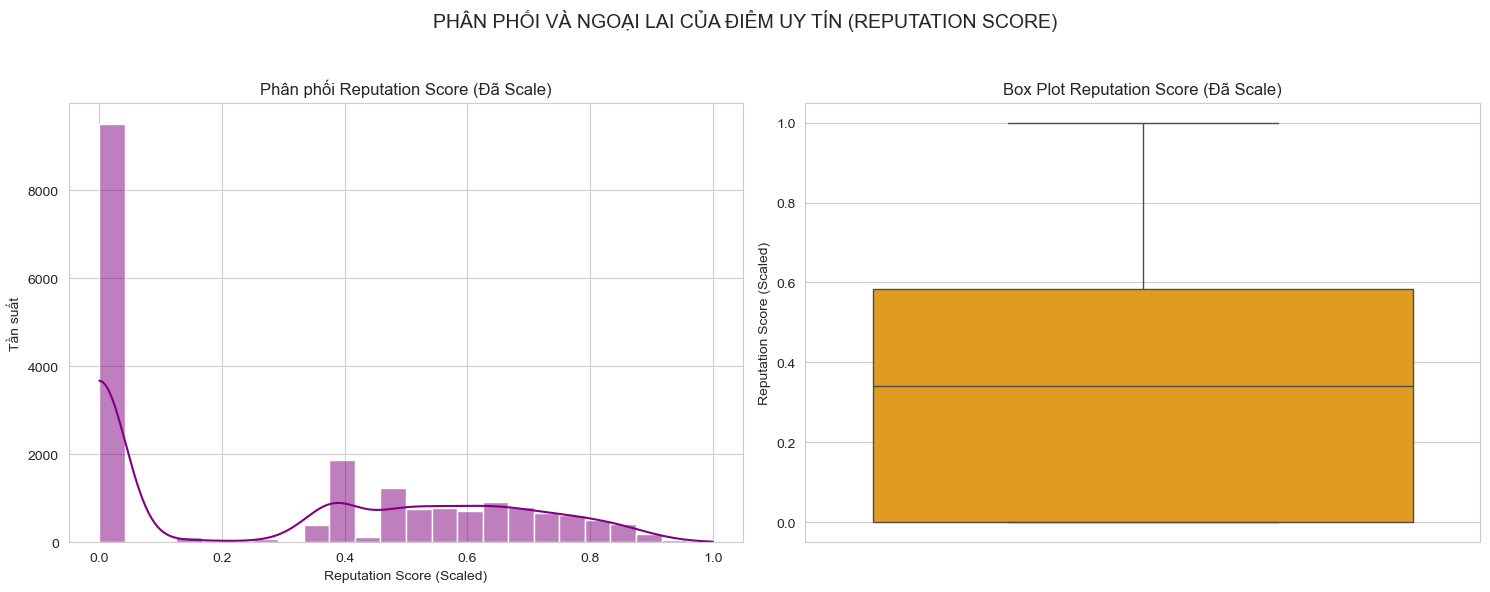

In [10]:
# CELL 4: II. PHÂN TÍCH ĐƠN BIẾN (tiếp theo)

# --- 5. Phân tích Phân phối Đặc trưng Mới (Ví dụ: reputation_score) ---
print("\n5. Phân phối của Đặc trưng Mới (Reputation Score)")

if 'reputation_score' in df_processed.columns:
    plt.figure(figsize=(15, 6))

    # Histogram cho Reputation Score
    plt.subplot(1, 2, 1)
    sns.histplot(df_processed['reputation_score'], kde=True, color='purple')
    plt.title('Phân phối Reputation Score (Đã Scale)')
    plt.xlabel('Reputation Score (Scaled)')
    plt.ylabel('Tần suất')

    # Box Plot cho Reputation Score
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_processed['reputation_score'], color='orange')
    plt.title('Box Plot Reputation Score (Đã Scale)')
    plt.ylabel('Reputation Score (Scaled)')

    plt.suptitle('PHÂN PHỐI VÀ NGOẠI LAI CỦA ĐIỂM UY TÍN (REPUTATION SCORE)', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
else:
    print("  => Không tìm thấy cột 'reputation_score' để phân tích.")


IIb. PHÂN TÍCH HIỆU ỨNG CỦA YẾU TỐ UY TÍN (BINARY vs. TARGET)


C:\Users\chiph\AppData\Local\Temp\ipykernel_54440\694952787.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='quantity_sold_log', data=df_log_analysis, palette='Pastel1')
C:\Users\chiph\AppData\Local\Temp\ipykernel_54440\694952787.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='quantity_sold_log', data=df_log_analysis, palette='Pastel1')
C:\Users\chiph\AppData\Local\Temp\ipykernel_54440\694952787.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='quantity_sold_log', data=df_log_analysis, palette='Paste

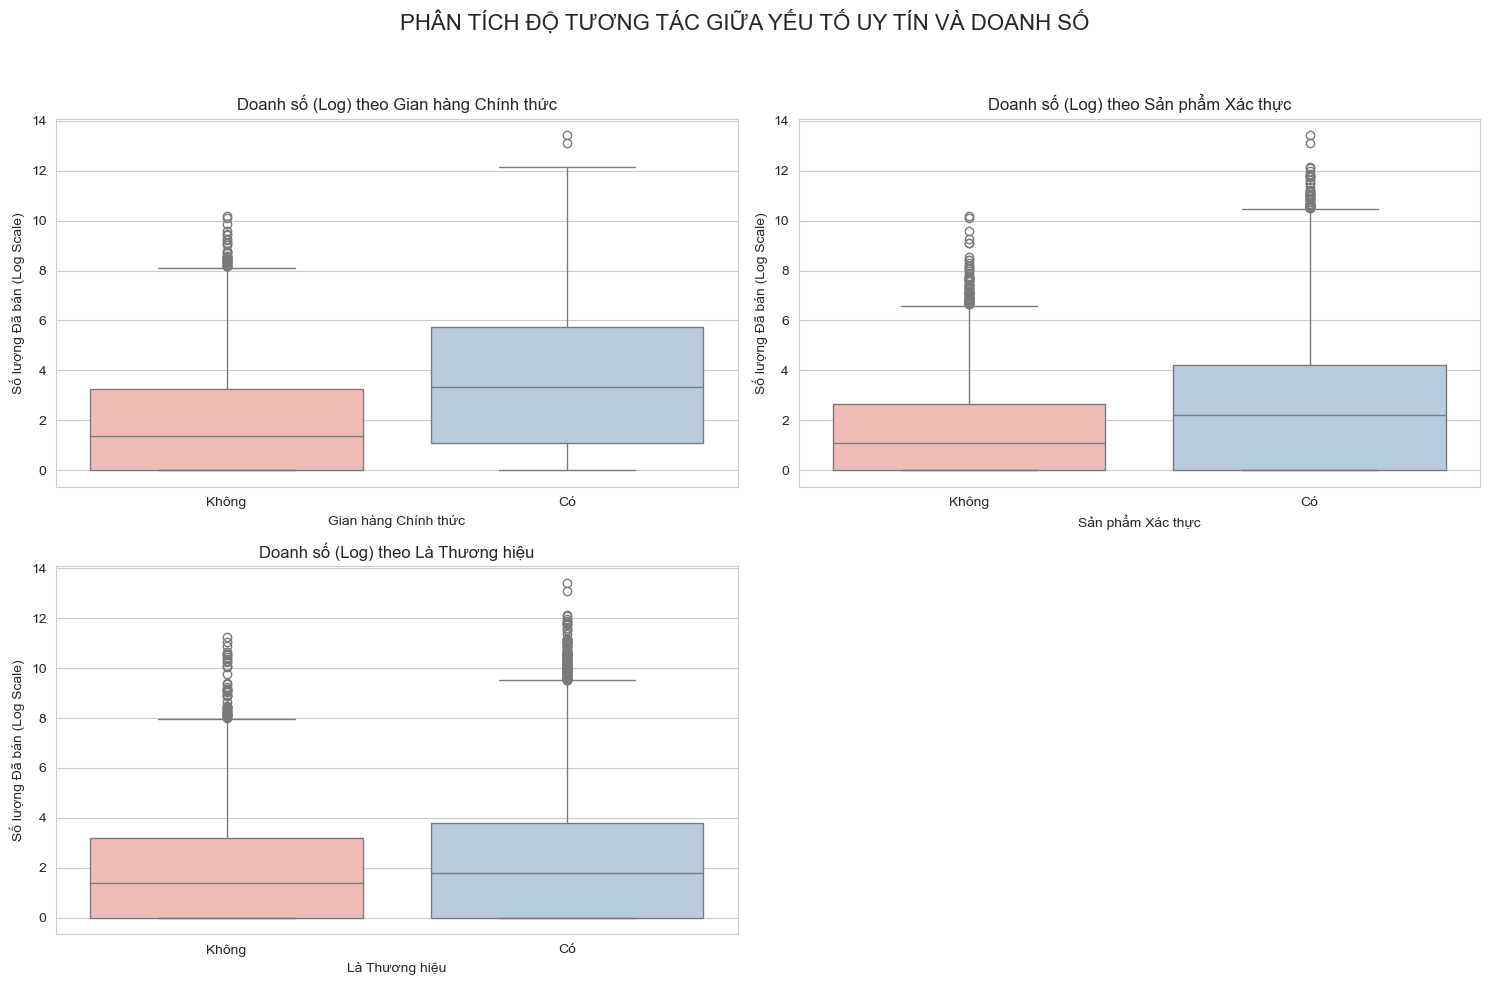


INSIGHTS từ Box Plots:
So sánh vị trí Median (đường kẻ giữa hộp) giữa nhóm 'Có' và 'Không' để đánh giá hiệu ứng.
Chiều cao của hộp (IQR) cho thấy mức độ phân tán của doanh số trong mỗi nhóm.


In [11]:
# CELL 3a: PHÂN TÍCH ĐA BIẾN (BINARY vs. TARGET)

print("\n" + "="*50)
print("IIb. PHÂN TÍCH HIỆU ỨNG CỦA YẾU TỐ UY TÍN (BINARY vs. TARGET)")
print("="*50)

# Chuẩn bị dữ liệu Log-transformed (Lấy từ df_raw đã được Log ở Cell 2)
df_log_analysis = df_raw.copy()
df_log_analysis['quantity_sold_log'] = np.log1p(df_raw['quantity_sold'].fillna(0))

binary_cols_to_analyze = ['is_official', 'is_authentic', 'is_brand', 'has_video']
display_names = ['Gian hàng Chính thức', 'Sản phẩm Xác thực', 'Là Thương hiệu', 'Có Video']

plt.figure(figsize=(15, 10))

for i, col in enumerate(binary_cols_to_analyze):
    if col in df_raw.columns:
        plt.subplot(2, 2, i + 1)
        
        # Đảm bảo cột Binary là kiểu category để Box Plot hiển thị đúng
        df_log_analysis[col] = df_log_analysis[col].astype('category').cat.rename_categories({0.0: 'Không', 1.0: 'Có'})
        
        # Vẽ Box Plot so sánh quantity_sold_log giữa 2 nhóm
        sns.boxplot(x=col, y='quantity_sold_log', data=df_log_analysis, palette='Pastel1')
        
        plt.title(f'Doanh số (Log) theo {display_names[i]}', fontsize=12)
        plt.xlabel(display_names[i], fontsize=10)
        plt.ylabel('Số lượng Đã bán (Log Scale)', fontsize=10)

plt.suptitle('PHÂN TÍCH ĐỘ TƯƠNG TÁC GIỮA YẾU TỐ UY TÍN VÀ DOANH SỐ', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\nINSIGHTS từ Box Plots:")
print("So sánh vị trí Median (đường kẻ giữa hộp) giữa nhóm 'Có' và 'Không' để đánh giá hiệu ứng.")
print("Chiều cao của hộp (IQR) cho thấy mức độ phân tán của doanh số trong mỗi nhóm.")

III. PHÂN TÍCH ĐA BIẾN (MỐI QUAN HỆ)

6. Ma trận Tương quan (Correlation Heatmap) - DỮ LIỆU ĐÃ LOG-TRANSFORM


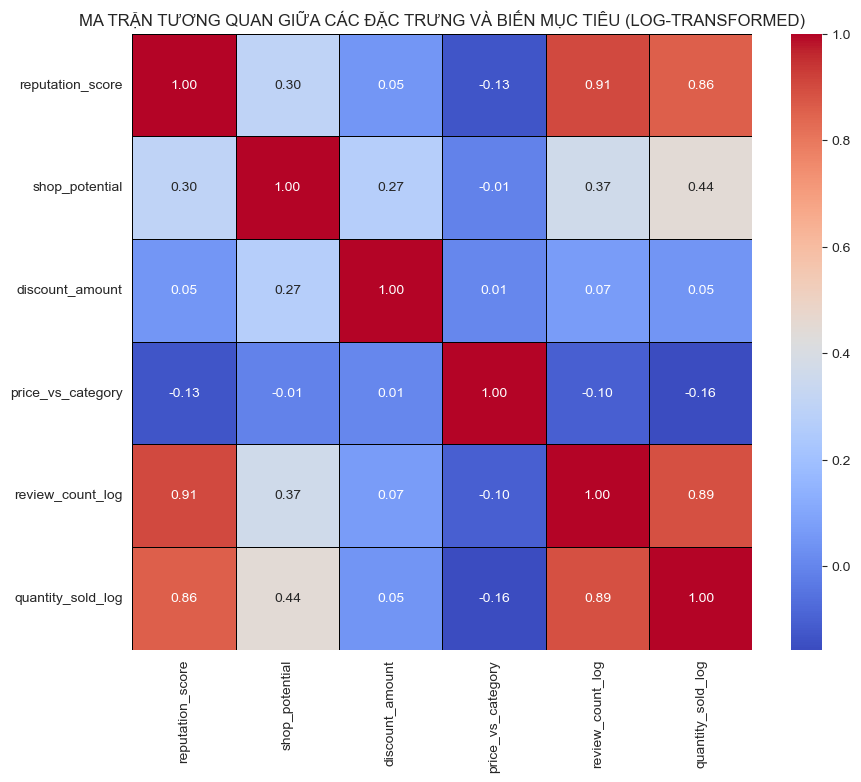


7. Biểu đồ Phân tán: Đặc trưng Tốt nhất vs. Quantity Sold
   => Đặc trưng có tương quan mạnh nhất với Quantity Sold (Log) là: review_count_log (r = 0.89)


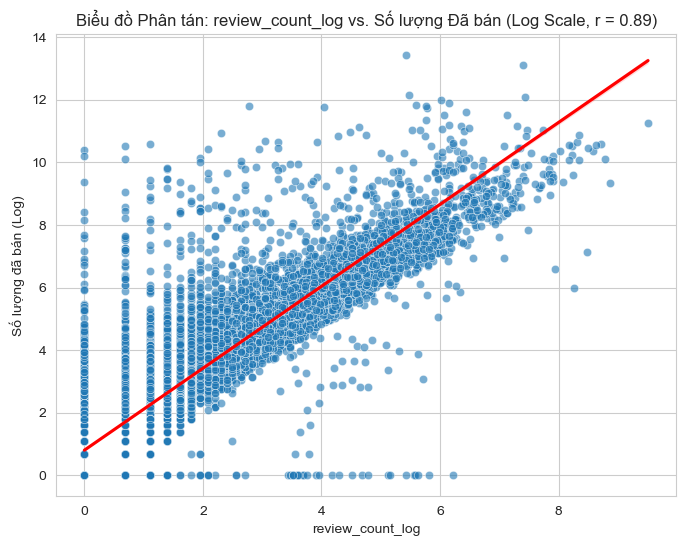

In [12]:
# CELL 5: III. PHÂN TÍCH ĐA BIẾN (MULTIVARIATE ANALYSIS)

print("="*50)
print("III. PHÂN TÍCH ĐA BIẾN (MỐI QUAN HỆ)")
print("="*50)

# --- TẠO LOG-TRANSFORMATION CHO CỘT GỐC (ĐỂ TRỰC QUAN HÓA) ---
# Sử dụng dữ liệu thô để tạo Log Transformation, tránh làm biến dạng thêm dữ liệu đã Scale
# Cần dùng file RAW hoặc file đã xử lý lỗi dữ liệu thô (từ Cell 1)
df_log_analysis = df_raw.copy()
df_log_analysis['review_count_log'] = np.log1p(df_log_analysis['review_count'].fillna(0))
df_log_analysis['quantity_sold_log'] = np.log1p(df_log_analysis['quantity_sold'].fillna(0))

# Tái định nghĩa các cột để tính toán tương quan (sử dụng cột đã Log cho phân tích)
LOG_FE_COLS = ['reputation_score', 'shop_potential', 'discount_amount', 'price_vs_category']
LOG_ANALYZE_COLS = ['price', 'review_count_log', 'total_follower', 'quantity_sold_log']

# --- 6. Ma trận Tương quan (Correlation Heatmap) ---
print("\n6. Ma trận Tương quan (Correlation Heatmap) - DỮ LIỆU ĐÃ LOG-TRANSFORM")

# Kết hợp các cột đã Log và các cột FE đã Scale (chỉ lấy các cột có trong df_processed)
df_corr = df_processed[[col for col in KEY_FE_COLS if col in df_processed.columns]].copy()

# Thêm các cột đã Log mới vào df_corr
df_corr['review_count_log'] = df_log_analysis['review_count_log']
df_corr['quantity_sold_log'] = df_log_analysis['quantity_sold_log']


if not df_corr.empty:
    correlation_matrix = df_corr.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
    plt.title('MA TRẬN TƯƠNG QUAN GIỮA CÁC ĐẶC TRƯNG VÀ BIẾN MỤC TIÊU (LOG-TRANSFORMED)')
    plt.show()

    # --- 7. Biểu đồ Phân tán (Scatter Plot) và Insight Tương quan ---
    print("\n7. Biểu đồ Phân tán: Đặc trưng Tốt nhất vs. Quantity Sold")

    # Tìm ra cột tương quan mạnh nhất với biến mục tiêu đã Log
    TARGET_LOG_COL = 'quantity_sold_log'
    if TARGET_LOG_COL in correlation_matrix.columns:
        corr_with_target = correlation_matrix[TARGET_LOG_COL].sort_values(ascending=False).iloc[1:6] # Bỏ qua chính nó
        
        # Đặc trưng tương quan mạnh nhất
        best_feature = corr_with_target.index[0]
        r_value = corr_with_target.iloc[0]

        print(f"   => Đặc trưng có tương quan mạnh nhất với Quantity Sold (Log) là: {best_feature} (r = {r_value:.2f})")

        # TRỰC QUAN HÓA BẰNG LOG-TRANSFORMED DATA
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=df_corr[best_feature], y=df_corr[TARGET_LOG_COL], alpha=0.6)
        
        # Thêm đường hồi quy tuyến tính (regression line) để minh họa mối quan hệ
        sns.regplot(x=df_corr[best_feature], y=df_corr[TARGET_LOG_COL], scatter=False, color='red')

        plt.title(f'Biểu đồ Phân tán: {best_feature} vs. Số lượng Đã bán (Log Scale, r = {r_value:.2f})')
        plt.xlabel(f'{best_feature}')
        plt.ylabel(f'Số lượng đã bán (Log)')
        plt.show()
    else:
        print("   => Không thể tính toán tương quan do thiếu cột mục tiêu.")

else:
    print("  => Không đủ cột để vẽ Ma trận Tương quan.")